In [1]:
import requests

In [2]:
url = "https://store.steampowered.com/api/appdetails?appids=730"

response = requests.get(url)

response.status_code

200

In [3]:
data = response.json()
data

{'730': {'success': True,
  'data': {'type': 'game',
   'name': 'Counter-Strike 2',
   'steam_appid': 730,
   'required_age': 0,
   'is_free': True,
   'dlc': [2678630],
   'detailed_description': 'For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2.<br><br>A free upgrade to CS:GO, Counter-Strike 2 marks the largest technical leap in Counter-Strike’s history. Built on the Source 2 engine, Counter-Strike 2 is modernized with realistic physically-based rendering, state of the art networking, and upgraded Community Workshop tools.<br><br>In addition to the classic objective-focused gameplay that Counter-Strike pioneered in 1999, Counter-Strike 2 features:<br><br><ul class="bb_ul"><li>All-new CS Ratings with the updated Premier mode<br></li><li>Global and Regional leaderboards<br></li><li>Upgraded and overhauled maps<br>

In [4]:
game = data['730']['data']

game['name']

'Counter-Strike 2'

In [5]:
game['steam_appid']

730

In [6]:
game['genres']

[{'id': '1', 'description': 'Action'},
 {'id': '37', 'description': 'Free To Play'}]

In [7]:
genres = [genre['description'] for genre in game['genres']]
genres

['Action', 'Free To Play']

In [8]:
game_record = {
    'appid': game['steam_appid'],
    'name': game['name'],
    'is_free': game['is_free'],
    'required_age': game['required_age'],
    'developers': game.get('developers', []),
    'publishers': game.get('publishers', []),
    'genres': [genre['description'] for genre in game.get('genres', [])],
    'recommendations': game.get('recommendations', {}).get('total', 0),
    'release_date': game.get('release_date', {}).get('date'),
    'windows': game.get('platforms', {}).get('windows', False),
    'mac': game.get('platforms', {}).get('mac', False),
    'linux': game.get('platforms', {}).get('linux', False),
    'price': game.get('price_overview', {}).get('final', 0) / 100
}

game_record

{'appid': 730,
 'name': 'Counter-Strike 2',
 'is_free': True,
 'required_age': 0,
 'developers': ['Valve'],
 'publishers': ['Valve'],
 'genres': ['Action', 'Free To Play'],
 'recommendations': 5251179,
 'release_date': '21 Aug, 2012',
 'windows': True,
 'mac': False,
 'linux': True,
 'price': 0.0}

In [9]:
game_record['price']

0.0

In [10]:
apps_url = "https://api.steampowered.com/ISteamApps/GetAppList/v2/"

apps_response = requests.get(apps_url)

apps_response.status_code

404

In [11]:
appids = [
    730,      # Counter-Strike 2
    570,      # Dota 2
    440,      # Team Fortress 2
    578080,   # PUBG
    1172470,  # Apex Legends
    271590,   # GTA V
    292030,   # The Witcher 3
    1091500,  # Cyberpunk 2077
    1245620,  # Elden Ring
    413150    # Stardew Valley
]

In [12]:
def get_game(appid):
    url = f"https://store.steampowered.com/api/appdetails?appids={appid}"
    response = requests.get(url)
    data = response.json()

    if not data[str(appid)]['success']:
        return None

    return data[str(appid)]['data']

In [13]:
get_game(570)['name']

'Dota 2'

In [14]:
games = []

In [15]:
for appid in appids:
    game = get_game(appid)

    if game is None:
        continue

    game_record = {
        'appid': game['steam_appid'],
        'name': game['name'],
        'is_free': game['is_free'],
        'required_age': game['required_age'],
        'developers': game.get('developers', []),
        'publishers': game.get('publishers', []),
        'genres': [genre['description'] for genre in game.get('genres', [])],
        'recommendations': game.get('recommendations', {}).get('total', 0),
        'release_date': game.get('release_date', {}).get('date'),
        'windows': game.get('platforms', {}).get('windows', False),
        'mac': game.get('platforms', {}).get('mac', False),
        'linux': game.get('platforms', {}).get('linux', False),
        'price': game.get('price_overview', {}).get('final', 0) / 100
    }

    games.append(game_record)

In [16]:
len(games)

10

In [17]:
games[:2]

[{'appid': 730,
  'name': 'Counter-Strike 2',
  'is_free': True,
  'required_age': 0,
  'developers': ['Valve'],
  'publishers': ['Valve'],
  'genres': ['Action', 'Free To Play'],
  'recommendations': 5251179,
  'release_date': '21 Aug, 2012',
  'windows': True,
  'mac': False,
  'linux': True,
  'price': 0.0},
 {'appid': 570,
  'name': 'Dota 2',
  'is_free': True,
  'required_age': 0,
  'developers': ['Valve'],
  'publishers': ['Valve'],
  'genres': ['Action', 'Strategy', 'Free To Play'],
  'recommendations': 14377,
  'release_date': '9 Jul, 2013',
  'windows': True,
  'mac': True,
  'linux': True,
  'price': 0.0}]

In [18]:
import pandas as pd

df = pd.DataFrame(games)

df

,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
0,730,Counter-Strike 2,True,0,[Valve],[Valve],"[Action, Free To Play]",5251179,"21 Aug, 2012",True,False,True,0.00
1,570,Dota 2,True,0,[Valve],[Valve],"[Action, Strategy, Free To Play]",14377,"9 Jul, 2013",True,True,True,0.00
2,440,Team Fortress 2,True,0,[Valve],[Valve],"[Action, Free To Play]",47800,"10 Oct, 2007",True,False,True,0.00
3,578080,PUBG: BATTLEGROUNDS,True,16,[PUBG Corporation],"[KRAFTON, Inc.]","[Action, Adventure, Massively Multiplayer, Fre...",1763191,"21 Dec, 2017",True,False,False,0.00
4,1172470,Apex Legends™,True,0,[Respawn],[Electronic Arts],"[Action, Adventure, Free To Play]",1580,"4 Nov, 2020",True,False,False,0.00
5,271590,Grand Theft Auto V Legacy,False,17,[Rockstar North],[Rockstar Games],"[Action, Adventure]",1893535,"13 Apr, 2015",True,False,False,0.00
6,292030,The Witcher 3: Wild Hunt - Complete Edition,False,18,[CD PROJEKT RED],[CD PROJEKT RED],[RPG],831611,"18 May, 2015",True,False,False,49.99
7,1091500,Cyberpunk 2077,False,18,[CD PROJEKT RED],[CD PROJEKT RED],[RPG],887089,"9 Dec, 2020",True,True,False,59.99
8,1245620,ELDEN RING,False,16,"[FromSoftware, Inc.]","[FromSoftware, Inc., Bandai Namco Entertainment]","[Action, RPG]",829843,"24 Feb, 2022",True,False,False,59.99
9,413150,Stardew Valley,False,0,[ConcernedApe],[ConcernedApe],"[Indie, RPG, Simulation]",891858,"26 Feb, 2016",True,True,True,16.99


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            10 non-null     int64  
 1   name             10 non-null     str    
 2   is_free          10 non-null     bool   
 3   required_age     10 non-null     object 
 4   developers       10 non-null     object 
 5   publishers       10 non-null     object 
 6   genres           10 non-null     object 
 7   recommendations  10 non-null     int64  
 8   release_date     10 non-null     str    
 9   windows          10 non-null     bool   
 10  mac              10 non-null     bool   
 11  linux            10 non-null     bool   
 12  price            10 non-null     float64
dtypes: bool(4), float64(1), int64(2), object(4), str(2)
memory usage: 888.0+ bytes


In [20]:
df.head()

,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
0,730,Counter-Strike 2,True,0,[Valve],[Valve],"[Action, Free To Play]",5251179,"21 Aug, 2012",True,False,True,0.0
1,570,Dota 2,True,0,[Valve],[Valve],"[Action, Strategy, Free To Play]",14377,"9 Jul, 2013",True,True,True,0.0
2,440,Team Fortress 2,True,0,[Valve],[Valve],"[Action, Free To Play]",47800,"10 Oct, 2007",True,False,True,0.0
3,578080,PUBG: BATTLEGROUNDS,True,16,[PUBG Corporation],"[KRAFTON, Inc.]","[Action, Adventure, Massively Multiplayer, Fre...",1763191,"21 Dec, 2017",True,False,False,0.0
4,1172470,Apex Legends™,True,0,[Respawn],[Electronic Arts],"[Action, Adventure, Free To Play]",1580,"4 Nov, 2020",True,False,False,0.0


In [21]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

df['developers'] = df['developers'].apply(lambda x: ', '.join(x))
df['publishers'] = df['publishers'].apply(lambda x: ', '.join(x))
df['genres'] = df['genres'].apply(lambda x: ', '.join(x))

df.head()

,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
0,730,Counter-Strike 2,True,0,Valve,Valve,"Action, Free To Play",5251179,2012-08-21,True,False,True,0.0
1,570,Dota 2,True,0,Valve,Valve,"Action, Strategy, Free To Play",14377,2013-07-09,True,True,True,0.0
2,440,Team Fortress 2,True,0,Valve,Valve,"Action, Free To Play",47800,2007-10-10,True,False,True,0.0
3,578080,PUBG: BATTLEGROUNDS,True,16,PUBG Corporation,"KRAFTON, Inc.","Action, Adventure, Massively Multiplayer, Free...",1763191,2017-12-21,True,False,False,0.0
4,1172470,Apex Legends™,True,0,Respawn,Electronic Arts,"Action, Adventure, Free To Play",1580,2020-11-04,True,False,False,0.0


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   appid            10 non-null     int64         
 1   name             10 non-null     str           
 2   is_free          10 non-null     bool          
 3   required_age     10 non-null     object        
 4   developers       10 non-null     str           
 5   publishers       10 non-null     str           
 6   genres           10 non-null     str           
 7   recommendations  10 non-null     int64         
 8   release_date     10 non-null     datetime64[us]
 9   windows          10 non-null     bool          
 10  mac              10 non-null     bool          
 11  linux            10 non-null     bool          
 12  price            10 non-null     float64       
dtypes: bool(4), datetime64[us](1), float64(1), int64(2), object(1), str(4)
memory usage: 888.0+ bytes


In [23]:
steamspy_url = "https://steamspy.com/api.php?request=all&page=0"

spy_response = requests.get(steamspy_url)
spy_response.status_code

200

In [24]:
spy_data = spy_response.json()

len(spy_data)

1000

In [25]:
list(spy_data.items())[:3]

[('730',
  {'appid': 730,
   'name': 'Counter-Strike: Global Offensive',
   'developer': 'Valve',
   'publisher': 'Valve',
   'score_rank': '',
   'positive': 7642084,
   'negative': 1173003,
   'userscore': 0,
   'owners': '100,000,000 .. 200,000,000',
   'average_forever': 0,
   'average_2weeks': 0,
   'median_forever': 0,
   'median_2weeks': 0,
   'price': '0',
   'initialprice': '0',
   'discount': '0',
   'ccu': 1013936}),
 ('1172470',
  {'appid': 1172470,
   'name': 'Apex Legends',
   'developer': 'Respawn',
   'publisher': 'Electronic Arts',
   'score_rank': '',
   'positive': 668053,
   'negative': 326926,
   'userscore': 0,
   'owners': '100,000,000 .. 200,000,000',
   'average_forever': 0,
   'average_2weeks': 0,
   'median_forever': 0,
   'median_2weeks': 0,
   'price': '0',
   'initialprice': '0',
   'discount': '0',
   'ccu': 124262}),
 ('578080',
  {'appid': 578080,
   'name': 'PUBG: BATTLEGROUNDS',
   'developer': 'PUBG Corporation',
   'publisher': 'KRAFTON, Inc.',
   '

In [26]:
appids_big = [int(appid) for appid in spy_data.keys()]

len(appids_big)

1000

In [27]:
appids_big[:10]

[730, 1172470, 578080, 1623730, 440, 1938090, 1063730, 2358720, 271590, 550]

In [28]:
import time

In [29]:
def get_game(appid):
    url = f"https://store.steampowered.com/api/appdetails?appids={appid}"

    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            return None

        data = response.json()

        if not data.get(str(appid), {}).get('success'):
            return None

        game = data[str(appid)]['data']

        # Нам нужны только игры, не DLC и не прочий контент
        if game.get('type') != 'game':
            return None

        return game

    except:
        return None

In [30]:
games_big = []

for i, appid in enumerate(appids_big[:100]):

    game = get_game(appid)

    if game is not None:

        game_record = {
            'appid': game['steam_appid'],
            'name': game['name'],
            'is_free': game.get('is_free', False),
            'required_age': game.get('required_age', 0),
            'developers': game.get('developers', []),
            'publishers': game.get('publishers', []),
            'genres': [
                genre['description']
                for genre in game.get('genres', [])
            ],
            'recommendations': game.get('recommendations', {}).get('total', 0),
            'release_date': game.get('release_date', {}).get('date'),
            'windows': game.get('platforms', {}).get('windows', False),
            'mac': game.get('platforms', {}).get('mac', False),
            'linux': game.get('platforms', {}).get('linux', False),
            'price': game.get('price_overview', {}).get('final', 0) / 100
        }

        games_big.append(game_record)

    time.sleep(0.5)

    if (i + 1) % 10 == 0:
        print(f'Обработано: {i + 1}/100')

Обработано: 10/100
Обработано: 20/100
Обработано: 30/100
Обработано: 40/100
Обработано: 50/100
Обработано: 60/100
Обработано: 70/100
Обработано: 80/100
Обработано: 90/100
Обработано: 100/100


In [31]:
len(games_big)

100

In [32]:

games_big = []

for i, appid in enumerate(appids_big):

    game = get_game(appid)

    if game is not None:

        game_record = {
            'appid': game['steam_appid'],
            'name': game['name'],
            'is_free': game.get('is_free', False),
            'required_age': game.get('required_age', 0),
            'developers': game.get('developers', []),
            'publishers': game.get('publishers', []),
            'genres': [
                genre['description']
                for genre in game.get('genres', [])
            ],
            'recommendations': game.get('recommendations', {}).get('total', 0),
            'release_date': game.get('release_date', {}).get('date'),
            'windows': game.get('platforms', {}).get('windows', False),
            'mac': game.get('platforms', {}).get('mac', False),
            'linux': game.get('platforms', {}).get('linux', False),
            'price': game.get('price_overview', {}).get('final', 0) / 100
        }

        games_big.append(game_record)

    time.sleep(0.5)

    if (i + 1) % 10 == 0:
        print(f'Обработано: {i + 1}/1000')
        pd.DataFrame(games_big).to_csv(
            'steam_games_progress.csv',
            index=False
        )
        print(f'Обработано: {i + 1}/1000')

Обработано: 10/1000
Обработано: 10/1000
Обработано: 20/1000
Обработано: 20/1000
Обработано: 30/1000
Обработано: 30/1000
Обработано: 40/1000
Обработано: 40/1000
Обработано: 50/1000
Обработано: 50/1000
Обработано: 60/1000
Обработано: 60/1000
Обработано: 70/1000
Обработано: 70/1000
Обработано: 80/1000
Обработано: 80/1000
Обработано: 90/1000
Обработано: 90/1000
Обработано: 100/1000
Обработано: 100/1000
Обработано: 110/1000
Обработано: 110/1000
Обработано: 120/1000
Обработано: 120/1000
Обработано: 130/1000
Обработано: 130/1000
Обработано: 140/1000
Обработано: 140/1000
Обработано: 150/1000
Обработано: 150/1000
Обработано: 160/1000
Обработано: 160/1000
Обработано: 170/1000
Обработано: 170/1000
Обработано: 180/1000
Обработано: 180/1000
Обработано: 190/1000
Обработано: 190/1000
Обработано: 200/1000
Обработано: 200/1000
Обработано: 210/1000
Обработано: 210/1000
Обработано: 220/1000
Обработано: 220/1000
Обработано: 230/1000
Обработано: 230/1000
Обработано: 240/1000
Обработано: 240/1000
Обработано

In [33]:
len(games_big)

913

In [34]:
df = pd.DataFrame(games_big)
df.head()

,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
0,730,Counter-Strike 2,True,0,[Valve],[Valve],"[Action, Free To Play]",5251179,"21 Aug, 2012",True,False,True,0.00
1,1172470,Apex Legends™,True,0,[Respawn],[Electronic Arts],"[Action, Adventure, Free To Play]",1580,"4 Nov, 2020",True,False,False,0.00
2,578080,PUBG: BATTLEGROUNDS,True,19,[PUBG Corporation],"[KRAFTON, Inc.]","[Action, Adventure, Massively Multiplayer, Fre...",1763188,"21 Dec, 2017",True,False,False,0.00
3,1623730,Palworld,False,0,[Pocketpair],[Pocketpair],"[Action, Adventure, Indie, RPG]",407997,"9 Jul, 2026",True,False,False,20.29
4,440,Team Fortress 2,True,0,[Valve],[Valve],"[Action, Free To Play]",47800,"10 Oct, 2007",True,False,True,0.00


In [35]:
df.shape

(913, 13)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            913 non-null    int64  
 1   name             913 non-null    str    
 2   is_free          913 non-null    bool   
 3   required_age     913 non-null    object 
 4   developers       913 non-null    object 
 5   publishers       913 non-null    object 
 6   genres           913 non-null    object 
 7   recommendations  913 non-null    int64  
 8   release_date     913 non-null    str    
 9   windows          913 non-null    bool   
 10  mac              913 non-null    bool   
 11  linux            913 non-null    bool   
 12  price            913 non-null    float64
dtypes: bool(4), float64(1), int64(2), object(4), str(2)
memory usage: 67.9+ KB


In [37]:
df.isna().sum()

appid              0
name               0
is_free            0
required_age       0
developers         0
publishers         0
genres             0
recommendations    0
release_date       0
windows            0
mac                0
linux              0
price              0
dtype: int64

In [38]:
df.duplicated(subset='appid').sum()

np.int64(7)

In [39]:
df.to_csv('steam_games_raw.csv', index=False)

In [40]:
df_clean = df.copy()

In [42]:
duplicates = df[df.duplicated(subset='appid', keep=False)]

duplicates.sort_values('appid')

,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
74,80,Counter-Strike: Condition Zero,False,0,[Valve],[Valve],[Action],21411,"1 Mar, 2004",True,True,True,8.19
118,80,Counter-Strike: Condition Zero,False,0,[Valve],[Valve],[Action],21411,"1 Mar, 2004",True,True,True,8.19
128,10180,Call of Duty®: Modern Warfare® 2 (2009),False,0,[Infinity Ward],[Activision],[Action],35648,"11 Nov, 2009",True,True,False,19.99
199,10180,Call of Duty®: Modern Warfare® 2 (2009),False,0,[Infinity Ward],[Activision],[Action],35647,"11 Nov, 2009",True,True,False,19.99
552,22330,The Elder Scrolls IV: Oblivion® Game of the Ye...,False,0,[Bethesda Game Studios®],[Bethesda Softworks],[],42901,"16 Jun, 2009",True,False,False,19.99
583,22330,The Elder Scrolls IV: Oblivion® Game of the Ye...,False,0,[Bethesda Game Studios],[Bethesda Softworks],[RPG],42901,"16 Jun, 2009",True,False,False,14.99
292,34330,Total War: SHOGUN 2,False,0,"[CREATIVE ASSEMBLY, Feral Interactive (Mac), F...","[SEGA, Feral Interactive (Mac), Feral Interact...",[Strategy],37910,"14 Mar, 2011",True,True,True,29.99
392,34330,Total War: SHOGUN 2,False,0,[The Creative Assembly],[SEGA],[],37910,,True,False,False,0.00
226,42680,Call of Duty®: Modern Warfare® 3 (2011),False,0,"[Infinity Ward, Sledgehammer Games]",[Activision],[Action],15491,"7 Nov, 2011",True,False,False,39.99
316,42680,Call of Duty®: Modern Warfare® 3 (2011),False,0,"[Infinity Ward, Sledgehammer Games]",[Activision],[Action],15491,"7 Nov, 2011",True,False,False,39.99


In [43]:
duplicate_ids = df.loc[
    df.duplicated(subset='appid', keep=False),
    'appid'
].unique()

duplicate_ids

array([    80,  10180,  42680, 202970,  34330,  22330, 209160])

In [44]:
for appid in duplicate_ids:
    display(df[df['appid'] == appid])

,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
74,80,Counter-Strike: Condition Zero,False,0,[Valve],[Valve],[Action],21411,"1 Mar, 2004",True,True,True,8.19
118,80,Counter-Strike: Condition Zero,False,0,[Valve],[Valve],[Action],21411,"1 Mar, 2004",True,True,True,8.19


,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
128,10180,Call of Duty®: Modern Warfare® 2 (2009),False,0,[Infinity Ward],[Activision],[Action],35648,"11 Nov, 2009",True,True,False,19.99
199,10180,Call of Duty®: Modern Warfare® 2 (2009),False,0,[Infinity Ward],[Activision],[Action],35647,"11 Nov, 2009",True,True,False,19.99


,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
226,42680,Call of Duty®: Modern Warfare® 3 (2011),False,0,"[Infinity Ward, Sledgehammer Games]",[Activision],[Action],15491,"7 Nov, 2011",True,False,False,39.99
316,42680,Call of Duty®: Modern Warfare® 3 (2011),False,0,"[Infinity Ward, Sledgehammer Games]",[Activision],[Action],15491,"7 Nov, 2011",True,False,False,39.99


,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
250,202970,Call of Duty®: Black Ops II,False,18,[Treyarch],[Activision],[Action],23238,"12 Nov, 2012",True,False,False,39.99
353,202970,Call of Duty®: Black Ops II,False,18,[Treyarch],[Activision],[Action],23238,"12 Nov, 2012",True,False,False,39.99


,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
292,34330,Total War: SHOGUN 2,False,0,"[CREATIVE ASSEMBLY, Feral Interactive (Mac), F...","[SEGA, Feral Interactive (Mac), Feral Interact...",[Strategy],37910,"14 Mar, 2011",True,True,True,29.99
392,34330,Total War: SHOGUN 2,False,0,[The Creative Assembly],[SEGA],[],37910,,True,False,False,0.00


,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
552,22330,The Elder Scrolls IV: Oblivion® Game of the Ye...,False,0,[Bethesda Game Studios®],[Bethesda Softworks],[],42901,"16 Jun, 2009",True,False,False,19.99
583,22330,The Elder Scrolls IV: Oblivion® Game of the Ye...,False,0,[Bethesda Game Studios],[Bethesda Softworks],[RPG],42901,"16 Jun, 2009",True,False,False,14.99


,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
819,209160,Call of Duty®: Ghosts,False,16,[Infinity Ward],[Activision],[Action],12898,"25 Mar, 2014",True,False,False,39.99
831,209160,Call of Duty®: Ghosts,False,16,[Infinity Ward],[Activision],[Action],12898,"25 Mar, 2014",True,False,False,39.99


In [45]:
for appid in duplicate_ids:
    group = df[df['appid'] == appid]

    print(f'\nAPPID: {appid}')

    for column in df.columns:
        values = group[column].astype(str).unique()

        if len(values) > 1:
            print(f'{column}: {values}')


APPID: 80

APPID: 10180
recommendations: <StringArray>
['35648', '35647']
Length: 2, dtype: str

APPID: 42680

APPID: 202970

APPID: 34330
developers: <StringArray>
['['CREATIVE ASSEMBLY', 'Feral Interactive (Mac)', 'Feral Interactive (Linux)']', '['The Creative Assembly']']
Length: 2, dtype: str
publishers: <StringArray>
['['SEGA', 'Feral Interactive (Mac)', 'Feral Interactive (Linux)']', '['SEGA']']
Length: 2, dtype: str
genres: <StringArray>
['['Strategy']', '[]']
Length: 2, dtype: str
release_date: <StringArray>
['14 Mar, 2011', '']
Length: 2, dtype: str
mac: <StringArray>
['True', 'False']
Length: 2, dtype: str
linux: <StringArray>
['True', 'False']
Length: 2, dtype: str
price: <StringArray>
['29.99', '0.0']
Length: 2, dtype: str

APPID: 22330
name: <StringArray>
['The Elder Scrolls IV: Oblivion® Game of the Year Edition Deluxe (2009)', 'The Elder Scrolls IV: Oblivion® Game of the Year Edition (2009)']
Length: 2, dtype: str
developers: <StringArray>
['['Bethesda Game Studios®']',

In [46]:
df_clean = df.copy()

df_clean['completeness'] = (
    df_clean['developers'].apply(lambda x: len(x) > 0).astype(int) +
    df_clean['publishers'].apply(lambda x: len(x) > 0).astype(int) +
    df_clean['genres'].apply(lambda x: len(x) > 0).astype(int) +
    (df_clean['release_date'] != '').astype(int) +
    ((df_clean['price'] > 0) | df_clean['is_free']).astype(int)
)

In [47]:
df_clean = (
    df_clean
    .sort_values(
        ['appid', 'completeness', 'recommendations'],
        ascending=[True, False, False]
    )
    .drop_duplicates(subset='appid', keep='first')
    .drop(columns='completeness')
    .reset_index(drop=True)
)

In [48]:
df_clean.shape

(906, 13)

In [49]:
df_clean.duplicated(subset='appid').sum()

np.int64(0)

In [50]:
print("Пустые developers:", df_clean['developers'].apply(lambda x: len(x) == 0).sum())
print("Пустые publishers:", df_clean['publishers'].apply(lambda x: len(x) == 0).sum())
print("Пустые genres:", df_clean['genres'].apply(lambda x: len(x) == 0).sum())
print("Пустые release_date:", (df_clean['release_date'] == '').sum())
print("Платные игры с price = 0:", ((df_clean['is_free'] == False) & (df_clean['price'] == 0)).sum())

Пустые developers: 0
Пустые publishers: 3
Пустые genres: 2
Пустые release_date: 12
Платные игры с price = 0: 95


In [51]:
import numpy as np

In [52]:
mask = (~df_clean['is_free']) & (df_clean['price'] == 0)

df_clean.loc[mask, 'price'] = np.nan

In [53]:
df_clean['price'].isna().sum()

np.int64(95)

In [54]:
df_clean['release_date'] = pd.to_datetime(
    df_clean['release_date'],
    errors='coerce'
)

In [55]:
df_clean['publishers'] = df_clean['publishers'].apply(
    lambda x: x if len(x) > 0 else None
)

df_clean['genres'] = df_clean['genres'].apply(
    lambda x: x if len(x) > 0 else None
)

In [56]:
df_clean['required_age'] = pd.to_numeric(
    df_clean['required_age'],
    errors='coerce'
)

In [57]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   appid            906 non-null    int64         
 1   name             906 non-null    str           
 2   is_free          906 non-null    bool          
 3   required_age     906 non-null    int64         
 4   developers       906 non-null    object        
 5   publishers       903 non-null    object        
 6   genres           904 non-null    object        
 7   recommendations  906 non-null    int64         
 8   release_date     857 non-null    datetime64[us]
 9   windows          906 non-null    bool          
 10  mac              906 non-null    bool          
 11  linux            906 non-null    bool          
 12  price            811 non-null    float64       
dtypes: bool(4), datetime64[us](1), float64(1), int64(3), object(3), str(1)
memory usage: 67.4+ KB


In [58]:
df_clean.isna().sum()

appid               0
name                0
is_free             0
required_age        0
developers          0
publishers          3
genres              2
recommendations     0
release_date       49
windows             0
mac                 0
linux               0
price              95
dtype: int64

In [60]:
bad_ids = df_clean.loc[
    df_clean['release_date'].isna(),
    'appid'
]

len(bad_ids)

49

In [61]:
bad_dates = (
    df[df['appid'].isin(bad_ids)]
    [['appid', 'name', 'release_date']]
    .drop_duplicates(subset='appid')
)

bad_dates.head(20)

,appid,name,release_date
13,2246340,Monster Hunter Wilds,"Feb 27, 2025"
34,12210,Grand Theft Auto IV: Complete Edition,
38,381210,Dead by Daylight,"Jun 14, 2016"
40,438100,VRChat,"Feb 1, 2017"
77,433850,Z1 Battle Royale,"Feb 28, 2018"
126,250900,The Binding of Isaac: Rebirth,"Nov 4, 2014"
137,306130,The Elder Scrolls® Online,"May 22, 2017"
142,242050,Assassin’s Creed® IV Black Flag™,
162,594570,Total War: WARHAMMER II,"Sep 28, 2017"
207,3240220,Grand Theft Auto V Enhanced,"Mar 4, 2025"


In [62]:
date_map = (
    df[['appid', 'release_date']]
    .drop_duplicates(subset='appid')
    .set_index('appid')['release_date']
)

df_clean['release_date_raw'] = df_clean['appid'].map(date_map)

In [63]:
df_clean['release_date'] = pd.to_datetime(
    df_clean['release_date_raw'],
    format='mixed',
    errors='coerce',
    dayfirst=False
)

In [64]:
df_clean['release_date'].isna().sum()

np.int64(14)

In [65]:
df_clean.loc[
    df_clean['release_date'].isna(),
    ['appid', 'name', 'release_date_raw']
].head(30)

,appid,name,release_date_raw
63,12210,Grand Theft Auto IV: Complete Edition,
84,24980,Mass Effect 2 (2010 Edition),
91,33900,Arma 2,
103,39140,FINAL FANTASY VII,
126,56400,"Warhammer 40,000: Dawn of War II: Retribution",
129,63380,Sniper Elite V2,
139,102500,Kingdoms of Amalur: Reckoning™,
158,202170,Sleeping Dogs,
194,214560,Mark of the Ninja,
215,224540,Ace of Spades: Battle Builder,


In [66]:
df_clean['release_date_raw'] = (
    df_clean['release_date_raw']
    .str.replace('авг.', 'Aug', regex=False)
    .str.replace('г.', '', regex=False)
    .str.replace('Mai', 'May', regex=False)
)

In [67]:
df_clean['release_date'] = pd.to_datetime(
    df_clean['release_date_raw'],
    format='mixed',
    errors='coerce'
)

In [68]:
df_clean['release_date'].isna().sum()

np.int64(12)

In [69]:
df_clean = df_clean.drop(columns='release_date_raw')

In [70]:
df_clean.to_csv('steam_games_clean.csv', index=False)

In [71]:
games_table = df_clean[
    [
        'appid',
        'name',
        'is_free',
        'required_age',
        'recommendations',
        'release_date',
        'windows',
        'mac',
        'linux',
        'price'
    ]
].copy()

games_table.head()

,appid,name,is_free,required_age,recommendations,release_date,windows,mac,linux,price
0,10,Counter-Strike,False,0,169602,2000-11-01,True,True,True,8.19
1,30,Day of Defeat,False,0,4473,2003-05-01,True,True,True,4.99
2,40,Deathmatch Classic,False,0,2452,2001-06-01,True,True,True,4.99
3,70,Half-Life,False,0,117094,1998-11-19,True,True,True,8.19
4,80,Counter-Strike: Condition Zero,False,0,21411,2004-03-01,True,True,True,8.19


In [72]:
game_genres = (
    df_clean[['appid', 'genres']]
    .explode('genres')
    .dropna()
)

game_genres.head()

,appid,genres
0,10,Action
1,30,Action
2,40,Action
3,70,Action
4,80,Action


In [73]:
genres_table = (
    game_genres[['genres']]
    .drop_duplicates()
    .reset_index(drop=True)
)

genres_table['genre_id'] = genres_table.index + 1

genres_table = genres_table[
    ['genre_id', 'genres']
].rename(columns={'genres': 'genre_name'})

genres_table.head()

,genre_id,genre_name
0,1,Action
1,2,Free To Play
2,3,Adventure
3,4,Animation & Modeling
4,5,Video Production


In [74]:
game_genres_table = (
    game_genres
    .merge(
        genres_table,
        left_on='genres',
        right_on='genre_name',
        how='left'
    )
    [['appid', 'genre_id']]
    .drop_duplicates()
    .reset_index(drop=True)
)

game_genres_table.head()

,appid,genre_id
0,10,1
1,30,1
2,40,1
3,70,1
4,80,1


In [75]:
game_genres_table.shape

(2373, 2)

In [76]:
game_genres_table.isna().sum()

appid       0
genre_id    0
dtype: int64

In [77]:
game_developers = (
    df_clean[['appid', 'developers']]
    .explode('developers')
    .dropna()
)

developers_table = (
    game_developers[['developers']]
    .drop_duplicates()
    .reset_index(drop=True)
)

developers_table['developer_id'] = developers_table.index + 1

developers_table = developers_table[
    ['developer_id', 'developers']
].rename(columns={'developers': 'developer_name'})

game_developers_table = (
    game_developers
    .merge(
        developers_table,
        left_on='developers',
        right_on='developer_name',
        how='left'
    )
    [['appid', 'developer_id']]
    .drop_duplicates()
    .reset_index(drop=True)
)

In [78]:
developers_table.head()

,developer_id,developer_name
0,1,Valve
1,2,Gearbox Software
2,3,Tripwire Interactive
3,4,Arkane Studios
4,5,id Software


In [79]:
game_developers_table.head()

,appid,developer_id
0,10,1
1,30,1
2,40,1
3,70,1
4,80,1


In [80]:
game_developers_table.isna().sum()

appid           0
developer_id    0
dtype: int64

In [81]:
game_publishers = (
    df_clean[['appid', 'publishers']]
    .explode('publishers')
    .dropna()
)

publishers_table = (
    game_publishers[['publishers']]
    .drop_duplicates()
    .reset_index(drop=True)
)

publishers_table['publisher_id'] = publishers_table.index + 1

publishers_table = publishers_table[
    ['publisher_id', 'publishers']
].rename(columns={'publishers': 'publisher_name'})

game_publishers_table = (
    game_publishers
    .merge(
        publishers_table,
        left_on='publishers',
        right_on='publisher_name',
        how='left'
    )
    [['appid', 'publisher_id']]
    .drop_duplicates()
    .reset_index(drop=True)
)

In [82]:
publishers_table.head()

,publisher_id,publisher_name
0,1,Valve
1,2,Tripwire Interactive
2,3,Ubisoft
3,4,Bethesda
4,5,Bethesda Softworks


In [83]:
game_publishers_table.head()

,appid,publisher_id
0,10,1
1,30,1
2,40,1
3,70,1
4,80,1


In [84]:
game_publishers_table.isna().sum()

appid           0
publisher_id    0
dtype: int64

In [85]:
import sqlite3

conn = sqlite3.connect('steam_games.db')

In [88]:
games_table.to_sql(
    'games',
    conn,
    if_exists='replace',
    index=False
)

genres_table.to_sql(
    'genres',
    conn,
    if_exists='replace',
    index=False
)

game_genres_table.to_sql(
    'game_genres',
    conn,
    if_exists='replace',
    index=False
)

developers_table.to_sql(
    'developers',
    conn,
    if_exists='replace',
    index=False
)

game_developers_table.to_sql(
    'game_developers',
    conn,
    if_exists='replace',
    index=False
)

publishers_table.to_sql(
    'publishers',
    conn,
    if_exists='replace',
    index=False
)

game_publishers_table.to_sql(
    'game_publishers',
    conn,
    if_exists='replace',
    index=False
)

1037

In [89]:
query = """
select name
from sqlite_master
where type = 'table';
"""

pd.read_sql_query(query, conn)

,name
0,games
1,genres
2,game_genres
3,developers
4,game_developers
5,publishers
6,game_publishers


In [91]:
query = """
select g.genre_name, count(*) as games_count
from game_genres gg join genres g on gg.genre_id = g.genre_id
group by g.genre_name
order by games_count desc
limit 10;
"""

pd.read_sql_query(query, conn)

,genre_name,games_count
0,Action,612
1,Adventure,345
2,Indie,330
3,RPG,233
4,Simulation,183
5,Strategy,180
6,Free To Play,159
7,Massively Multiplayer,108
8,Casual,107
9,Early Access,33


In [96]:
pd.read_sql_query("""
SELECT *
FROM developers
LIMIT 10;
""", conn)

,developer_id,developer_name
0,1,Valve
1,2,Gearbox Software
2,3,Tripwire Interactive
3,4,Arkane Studios
4,5,id Software
5,6,Nightdive Studios
6,7,MachineGames
7,8,"PopCap Games, Inc."
8,9,Firaxis Games
9,10,Facepunch Studios


In [94]:
pd.read_sql_query("""
SELECT *
FROM game_developers
LIMIT 10;
""", conn)

,appid,developer_id
0,10,1
1,30,1
2,40,1
3,70,1
4,80,1
5,130,2
6,220,1
7,240,1
8,280,1
9,300,1


In [97]:

query = """
select d.developer_name, count(*) as games_count
from developers d join game_developers gd on d.developer_id = gd.developer_id
group by d.developer_name
order by games_count desc
limit 10;
"""

pd.read_sql_query(query, conn)

,developer_name,games_count
0,Valve,27
1,Feral Interactive (Mac),22
2,Feral Interactive (Linux),17
3,"CAPCOM Co., Ltd.",15
4,CREATIVE ASSEMBLY,11
5,Bethesda Game Studios,10
6,Firaxis Games,9
7,Ubisoft Montreal,8
8,Relic Entertainment,8
9,DICE,8


In [98]:
query = """
select *
from games
"""

pd.read_sql_query(query, conn)

,appid,name,is_free,required_age,recommendations,release_date,windows,mac,linux,price
0,10,Counter-Strike,0,0,169602,2000-11-01 00:00:00,1,1,1,8.19
1,30,Day of Defeat,0,0,4473,2003-05-01 00:00:00,1,1,1,4.99
2,40,Deathmatch Classic,0,0,2452,2001-06-01 00:00:00,1,1,1,4.99
3,70,Half-Life,0,0,117094,1998-11-19 00:00:00,1,1,1,8.19
4,80,Counter-Strike: Condition Zero,0,0,21411,2004-03-01 00:00:00,1,1,1,8.19
...,...,...,...,...,...,...,...,...,...,...
901,3132990,Black Myth: Wukong Benchmark Tool,1,0,0,2024-08-12 00:00:00,1,0,0,0.00
902,3146520,WEBFISHING,0,0,57320,2024-10-11 00:00:00,1,0,0,4.99
903,3164500,Schedule I,0,0,287697,2025-03-24 00:00:00,1,0,0,19.50
904,3240220,Grand Theft Auto V Enhanced,0,17,206393,2025-03-04 00:00:00,1,0,0,19.79


In [100]:
query = """
select name, price
from games
where is_free = 0 AND price IS NOT NULL
order by price desc
limit 10;
"""

pd.read_sql_query(query, conn)

,name,price
0,Hogwarts Legacy,79900.00
1,ELDEN RING,2399.00
2,TEKKEN 8,1695.00
3,Fallout 3: Game of the Year Edition,899.00
4,Mafia,365.00
5,The Long Dark,271.00
6,Battlefield™ 2042,79.99
7,Black Myth: Wukong,79.99
8,Need for Speed™ Heat,69.99
9,Microsoft Flight Simulator (2020) 40th Anniver...,69.99


In [101]:
query = """
SELECT
    g.genre_name,
    AVG(gs.price) AS avg_price
FROM games gs
JOIN game_genres gg
    ON gs.appid = gg.appid
JOIN genres g
    ON gg.genre_id = g.genre_id
WHERE gs.is_free = 0
  AND gs.price IS NOT NULL
GROUP BY g.genre_name
ORDER BY avg_price DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,genre_name,avg_price
0,RPG,505.634971
1,Adventure,311.222734
2,Стратегии,271.000000
3,Симуляторы,271.000000
4,Приключенческие игры,271.000000
5,Инди,271.000000
6,Action,207.615536
7,Sport,39.990000
8,Simulationen,39.990000
9,Rennspiele,39.990000


In [104]:
import time
import requests

def get_price_info(appid):
    url = "https://store.steampowered.com/api/appdetails"

    params = {
        'appids': appid,
        'cc': 'us',
        'l': 'english'
    }

    try:
        response = requests.get(
            url,
            params=params,
            timeout=15,
            headers={'User-Agent': 'Mozilla/5.0'}
        )

        response.raise_for_status()

        data = response.json()
        game_data = data.get(str(appid), {})

        if not game_data.get('success'):
            return None, None

        game = game_data['data']

        if game.get('is_free', False):
            return 0, 'USD'

        price_info = game.get('price_overview')

        if not price_info:
            return None, None

        price = price_info.get('final') / 100
        currency = price_info.get('currency')

        return price, currency

    except requests.exceptions.RequestException:
        return None, None

In [105]:
test_prices = []

for appid in df_clean['appid'].head(5):
    price, currency = get_price_info(appid)

    test_prices.append({
        'appid': appid,
        'price_new': price,
        'currency': currency
    })

    time.sleep(1)

test_prices

[{'appid': 10, 'price_new': 9.99, 'currency': 'USD'},
 {'appid': 30, 'price_new': 4.99, 'currency': 'USD'},
 {'appid': 40, 'price_new': None, 'currency': None},
 {'appid': 70, 'price_new': 9.99, 'currency': 'USD'},
 {'appid': 80, 'price_new': None, 'currency': None}]

In [106]:
price_rows = []

for i, appid in enumerate(df_clean['appid']):
    price, currency = get_price_info(appid)

    price_rows.append({
        'appid': appid,
        'price_usd': price,
        'currency': currency
    })

    time.sleep(1)

    if (i + 1) % 100 == 0:
        pd.DataFrame(price_rows).to_csv(
            'steam_prices_progress.csv',
            index=False
        )
        print(f'Обработано: {i + 1}/{len(df_clean)}')

Обработано: 100/906
Обработано: 200/906
Обработано: 300/906
Обработано: 400/906
Обработано: 500/906
Обработано: 600/906
Обработано: 700/906
Обработано: 800/906
Обработано: 900/906


In [107]:
prices_df = pd.DataFrame(price_rows)

prices_df['currency'].value_counts(dropna=False)

currency
USD    685
NaN    221
Name: count, dtype: int64

In [108]:
prices_df['price_usd'].isna().sum()

np.int64(221)

In [109]:
df_clean = df_clean.merge(
    prices_df[['appid', 'price_usd', 'currency']],
    on='appid',
    how='left'
)

In [110]:
df_clean = df_clean.drop(columns='price')

In [111]:
df_clean = df_clean.rename(columns={'price_usd': 'price'})

In [112]:
df_clean[['name', 'price', 'currency']].head(10)

,name,price,currency
0,Counter-Strike,NaN,NaN
1,Day of Defeat,4.99,USD
2,Deathmatch Classic,NaN,NaN
3,Half-Life,9.99,USD
4,Counter-Strike: Condition Zero,NaN,NaN
5,Half-Life: Blue Shift,4.99,USD
6,Half-Life 2,9.99,USD
7,Counter-Strike: Source,NaN,NaN
8,Half-Life: Source,NaN,NaN
9,Day of Defeat: Source,NaN,NaN


In [113]:
games_table = df_clean[
    [
        'appid',
        'name',
        'is_free',
        'required_age',
        'recommendations',
        'release_date',
        'windows',
        'mac',
        'linux',
        'price',
        'currency'
    ]
].copy()

In [114]:
games_table.to_sql(
    'games',
    conn,
    if_exists='replace',
    index=False
)

906

In [115]:
pd.read_sql_query("""
SELECT name, price, currency
FROM games
WHERE price IS NOT NULL
ORDER BY price DESC
LIMIT 10;
""", conn)

,name,price,currency
0,Need for Speed™ Heat,69.99,USD
1,STAR WARS Jedi: Survivor™,69.99,USD
2,No Man's Sky,59.99,USD
3,Sid Meier’s Civilization® VI,59.99,USD
4,Call of Duty®: Infinite Warfare,59.99,USD
5,Call of Duty®: Black Ops III,59.99,USD
6,Total War: WARHAMMER,59.99,USD
7,Marvel's Midnight Suns,59.99,USD
8,DARK SOULS™ III,59.99,USD
9,Borderlands 3,59.99,USD


In [116]:
avg_price = pd.read_sql_query("""
SELECT AVG(price) AS avg_price
FROM games
WHERE is_free = 0
  AND price IS NOT NULL;
""", conn)

avg_price

,avg_price
0,23.110444


In [117]:
median_price = games_table.loc[
    (games_table['is_free'] == False) &
    (games_table['price'].notna()),
    'price'
].median()

median_price

np.float64(19.99)

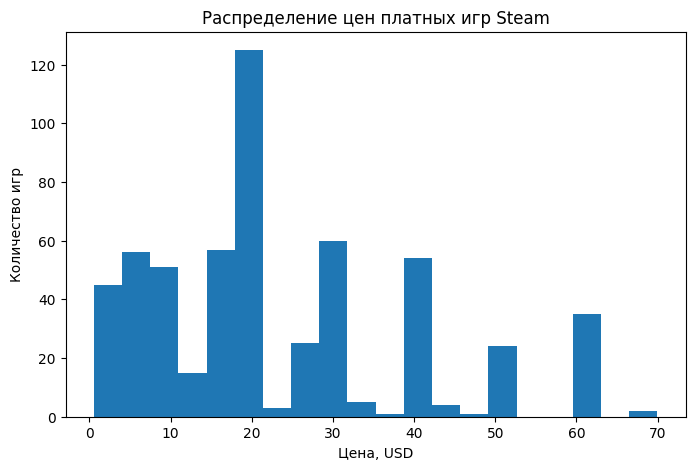

In [118]:
import matplotlib.pyplot as plt

paid_prices = games_table.loc[
    (games_table['is_free'] == False) &
    (games_table['price'].notna()),
    'price'
]

plt.figure(figsize=(8, 5))
plt.hist(paid_prices, bins=20)

plt.title('Распределение цен платных игр Steam')
plt.xlabel('Цена, USD')
plt.ylabel('Количество игр')

plt.show()

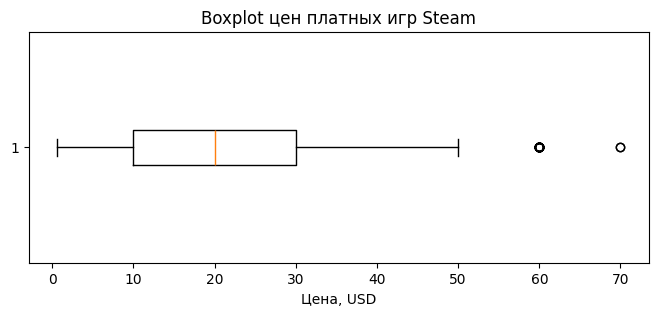

In [119]:
plt.figure(figsize=(8, 3))
plt.boxplot(paid_prices, vert=False)

plt.title('Boxplot цен платных игр Steam')
plt.xlabel('Цена, USD')

plt.show()

In [120]:
genre_stats = pd.read_sql_query("""
SELECT
    g.genre_name,
    COUNT(DISTINCT gg.appid) AS games_count,
    AVG(gs.price) AS avg_price
FROM game_genres gg
JOIN genres g
    ON gg.genre_id = g.genre_id
JOIN games gs
    ON gg.appid = gs.appid
GROUP BY g.genre_name
ORDER BY games_count DESC;
""", conn)

genre_stats.head(10)

,genre_name,games_count,avg_price
0,Action,612,20.078143
1,Adventure,345,20.413060
2,Indie,330,13.452143
3,RPG,233,21.324263
4,Simulation,183,16.433028
5,Strategy,180,19.544779
6,Free To Play,159,0.000000
7,Massively Multiplayer,108,8.162877
8,Casual,107,10.403678
9,Early Access,33,16.366429


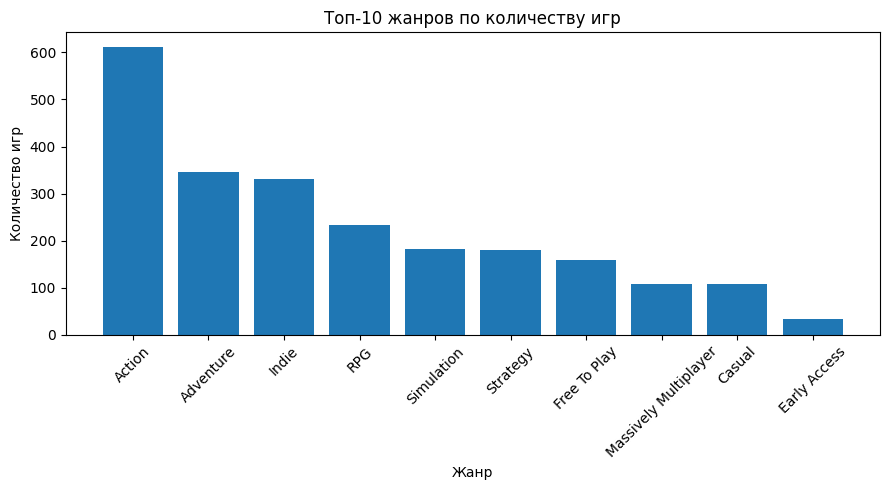

In [121]:
top_genres = genre_stats.head(10)

plt.figure(figsize=(9, 5))
plt.bar(top_genres['genre_name'], top_genres['games_count'])
plt.xticks(rotation=45)
plt.title('Топ-10 жанров по количеству игр')
plt.xlabel('Жанр')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()

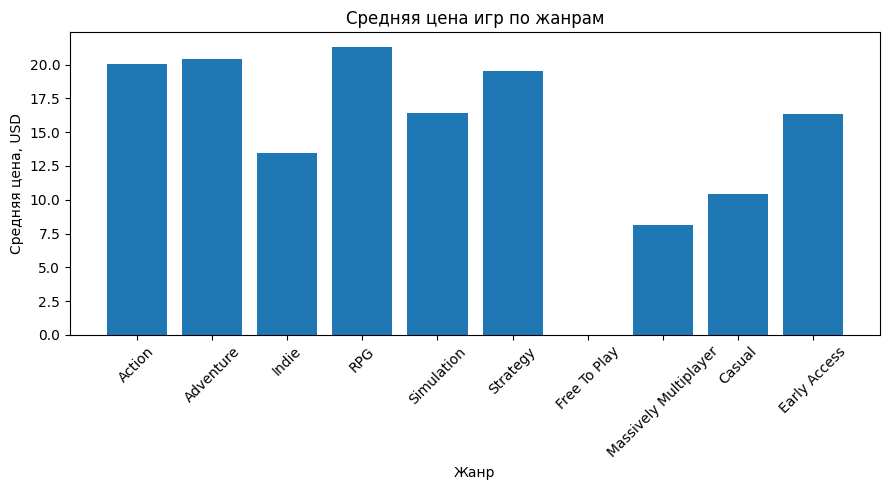

In [122]:
plt.figure(figsize=(9, 5))
plt.bar(top_genres['genre_name'], top_genres['avg_price'])
plt.xticks(rotation=45)
plt.title('Средняя цена игр по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Средняя цена, USD')
plt.tight_layout()
plt.show()

In [123]:
free_paid_stats = pd.read_sql_query("""
SELECT
    is_free,
    COUNT(*) AS games_count,
    AVG(recommendations) AS avg_recommendations
FROM games
GROUP BY is_free;
""", conn)

free_paid_stats

,is_free,games_count,avg_recommendations
0,0,768,89000.777344
1,1,138,68897.420290


In [124]:
recommendation_medians = games_table.groupby('is_free')['recommendations'].median()

recommendation_medians

is_free
False    38919.0
True       333.5
Name: recommendations, dtype: float64

In [125]:
recommendation_stats = games_table.groupby('is_free')['recommendations'].agg(
    ['count', 'mean', 'median']
)

recommendation_stats

,count,mean,median
is_free,,,
False,768,89000.777344,38919.0
True,138,68897.420290,333.5


In [126]:
top_developers = pd.read_sql_query("""
SELECT
    d.developer_name,
    COUNT(DISTINCT gd.appid) AS games_count
FROM game_developers gd
JOIN developers d
    ON gd.developer_id = d.developer_id
GROUP BY d.developer_name
ORDER BY games_count DESC
LIMIT 10;
""", conn)

top_developers

,developer_name,games_count
0,Valve,27
1,Feral Interactive (Mac),22
2,Feral Interactive (Linux),17
3,"CAPCOM Co., Ltd.",15
4,CREATIVE ASSEMBLY,11
5,Bethesda Game Studios,10
6,Firaxis Games,9
7,Ubisoft Montreal,8
8,Relic Entertainment,8
9,DICE,8


In [127]:
top_publishers = pd.read_sql_query("""
SELECT
    p.publisher_name,
    COUNT(DISTINCT gp.appid) AS games_count
FROM game_publishers gp
JOIN publishers p
    ON gp.publisher_id = p.publisher_id
GROUP BY p.publisher_name
ORDER BY games_count DESC
LIMIT 10;
""", conn)

top_publishers

,publisher_name,games_count
0,Electronic Arts,39
1,2K,32
2,Valve,28
3,SEGA,27
4,Bethesda Softworks,26
5,Ubisoft,23
6,Feral Interactive (Mac),21
7,Xbox Game Studios,20
8,Feral Interactive (Linux),17
9,Devolver Digital,16


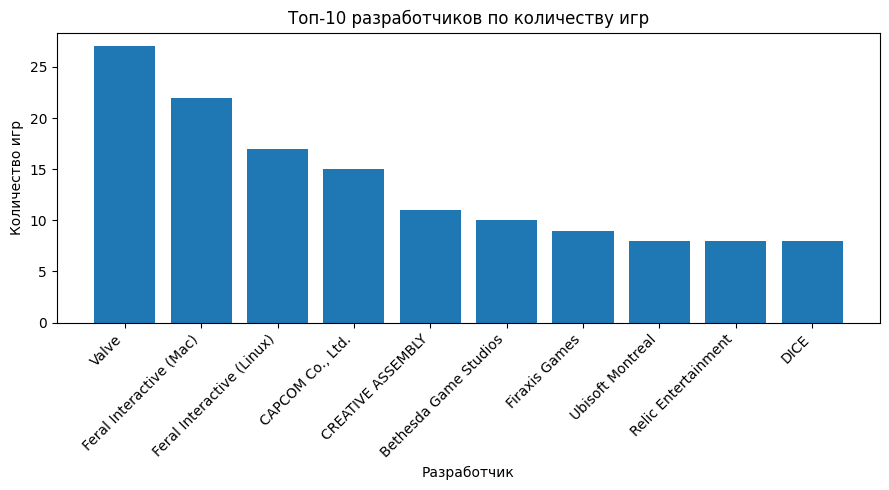

In [128]:
plt.figure(figsize=(9, 5))
plt.bar(top_developers['developer_name'], top_developers['games_count'])
plt.xticks(rotation=45, ha='right')
plt.title('Топ-10 разработчиков по количеству игр')
plt.xlabel('Разработчик')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()

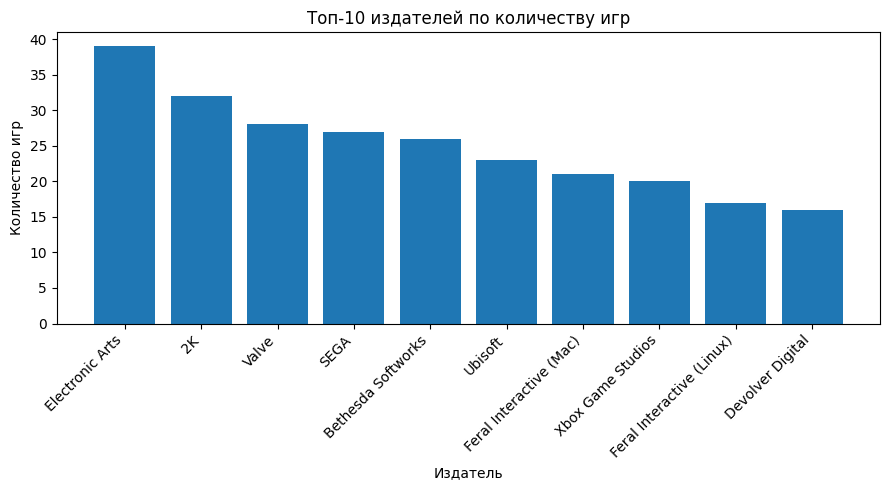

In [129]:
plt.figure(figsize=(9, 5))
plt.bar(top_publishers['publisher_name'], top_publishers['games_count'])
plt.xticks(rotation=45, ha='right')
plt.title('Топ-10 издателей по количеству игр')
plt.xlabel('Издатель')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()